In [1]:
from collections import defaultdict
# defaultdict는 조회 시 항목을 삽입함

# TODO: 이중 연결 리스트?

# https://github.com/Uniswap/v3-core/blob/main/contracts/libraries/TickBitmap.sol

I24_MAX = 2**23 - 1
I24_MIN = -2**23
U256_MAX = 2**256 - 1

def msb(u256):
    assert 0 < u256 <= 2**256 - 1
    x = u256
    i = 0
    if x >= 2**128:
        x >>= 128
        i += 128
    if x >= 2**64:
        x >>= 64
        i += 64
    if x >= 2**32:
        x >>= 32
        i += 32
    if x >= 2**16:
        x >>= 16
        i += 16
    if x >= 2**8:
        x >>= 8
        i += 8
    if x >= 2**4:
        x >>= 4
        i += 4
    if x >= 2**2:
        x >>= 2
        i += 2
    if x >= 2:
        # x >>= 1
        i += 1       
    return i


def lsb(u256):
    assert 0 < u256 <= 2**256 - 1
    x = u256
    i = 255
    if x & ((1 << 128) - 1) > 0:
        i -= 128
    else:
        x >>= 128
    if x & ((1 << 64) - 1) > 0:
        i -= 64
    else:
        x >>= 64
    if x & ((1 << 32) - 1) > 0:
        i -= 32
    else:
        x >>= 32
    if x & ((1 << 16) - 1) > 0:
        i -= 16
    else:
        x >>= 16
    if x & ((1 << 8) - 1) > 0:
        i -= 8
    else:
        x >>= 8
    if x & ((1 << 4) - 1) > 0:
        i -= 4
    else:
        x >>= 4
    if x & ((1 << 2) - 1) > 0:
        i -= 2
    else:
        x >>= 2
    if x & ((1 << 1) - 1) > 0:
        i -= 1    
    return i

def split(i24):
    hi = (i24 >> 8) & 0xFFFF
    lo = i24 & 0xFF
    #       u16, u8
    assert hi >= 0
    assert lo >= 0
    return (hi, lo)

def int24(val: int) -> int:
    # 24비트로 마스킹
    val &= 0xFFFFFF
    # 최상위 비트가 1이면 부호 있는 값으로 변환
    if val & 0x800000:
        val -= 0x1000000
    return val

class TickBitmap:
    @staticmethod
    def insert(ticks, i24, tick_spacing):
        assert i24 % tick_spacing == 0
        (hi, lo) = split(i24 // tick_spacing)
        ticks[hi] |= (1 << lo)

    @staticmethod    
    def remove(ticks, i24, tick_spacing):
        assert i24 % tick_spacing == 0
        (hi, lo) = split(i24 // tick_spacing)
        ticks[hi] &= (U256_MAX & ~(1 << lo))

    @staticmethod   
    def next(ticks, i24, tick_spacing, gt = True):
        assert i24 % tick_spacing == 0
        (hi, lo) = split(i24 // tick_spacing)
        if gt:
            # 왼쪽으로 틱 비트 탐색
            mask = ~((1 << lo) + ((1 << lo) - 1))
            bits = ticks[hi] & mask
            if bits > 0:
                # TODO: 올바른가? tick_spacing 계산 확인
                return int24((hi << 8) + lsb(bits)) * tick_spacing, True
            else:
                return int24((hi + 1) << 8) * tick_spacing, False
        else:
            # 오른쪽으로 틱 비트 탐색
            mask = (1 << lo) - 1
            bits = ticks[hi] & mask
            if bits > 0:
                # TODO: 올바른가?
                return int(int24((hi << 8) + msb(bits)) * tick_spacing), True
            else:
                return int(int24((hi << 8) - 1) * tick_spacing), False

class Bucket:
    def __init__(self, zero_to_one):
        self.zero_to_one = zero_to_one
        self.amt0 = 0
        self.amt1 = 0
        self.amt_out_rem = 0
        self.total = 0
        self.rem = 0
        self.amt_ins = defaultdict(int)
        # 디버깅에만 사용
        self.filled = False

    def inc(self, user, amt):
        self.total += amt
        self.rem += amt
        self.amt_ins[user] += amt

    def dec(self, user, amt):
        self.total -= amt
        self.rem -= amt
        self.amt_ins[user] -= amt

    def __repr__(self):
        return f'zero_to_one: {self.zero_to_one} | amt0: {self.amt0} | amt1: {self.amt1} | filled: {self.filled} | total: {self.total} | amt_ins: {self.amt_ins}'

P1 = 1.01


class OrderBook:
    def __init__(self, tick, tick_spacing):
        assert tick % tick_spacing == 0
        self.tick = tick
        self.tick_spacing = tick_spacing
        # 매핑 u16 => u256
        self.tick_bitmap = defaultdict(int)
        self.dp = P1**tick_spacing
        self.p = P1**tick
        # 버킷 id => 슬롯
        self.slots = {}
        # 버킷 id => 슬롯 => Bucket
        self.buckets = {}

    def get_bucket_id(self, tick):
        return f'{tick}'

    # amt_delta >= 0 = 입력량, amt_out >= min_amt_out
    # amt_delta < 0 = 출력량, amt_in <= max_amt_in
    def swap(self, amt_delta, amt_limit, tick_limit, zero_to_one):
        # P1 = 1.0001
        # p = P1^tick = Y (USDC)로 표시한 X (ETH)의 가격
        # px = y

        #            Y | X
        # - tick <- 1  | 0 -> + tick
        # assert tick_limit % tick_spacing == 0, "tick limit not a multiple of tick spacing"
        if zero_to_one:
            assert tick_limit <= self.tick
        else:
            assert tick_limit >= self.tick

        gas = 0
        p = self.p
        t = self.tick
        rem = amt_delta
        amt_in = 0
        amt_out = 0
        while rem != 0 and ((tick_limit <= t) if zero_to_one else (tick_limit >= t)):
            assert gas < 100, "out of gas"
            gas += 1

            i = self.get_bucket_id(t)
            s = self.slots.get(i, 0)
            bucket = self.buckets.get(i, {}).get(s, None)
            
            # print(
            #     "swap", "gas", gas, 
            #     "tick", t, 
            #     "p", p, 
            #     "rem", rem, 
            #     "slot", s, 
            #     "amt0", bucket.amt0 if bucket != None else None,
            #     "amt1", bucket.amt1 if bucket != None else None, 
            #     "zero_to_one", bucket.zero_to_one if bucket != None else None            
            # )
            
            if bucket != None and bucket.total > 0:
                d_in = 0
                d_out = 0
                # TODO: 최대 입력량과 출력량을 계산하는 수학 함수
                # px = y
                # rem >= 0 = amt_in_rem
                # rem < 0 = amt_out_rem 
                if zero_to_one:
                    # y <- x
                    max_out = bucket.amt1
                    max_in = max_out / p
                    if rem >= 0:
                        # rem = x, 입력 = x, 출력 = y
                        d_in = min(max_in, rem)
                        d_out = min(max_out, rem * p)
                    else:
                        # rem = y, 입력 = x, 출력 = y
                        d_in = min(max_in, -rem / p)
                        d_out = min(max_out, -rem)
                    bucket.amt0 += d_in
                    bucket.amt1 -= d_out
                    assert bucket.amt1 >= 0
                else:
                    # y -> x
                    max_out = bucket.amt0
                    max_in = max_out * p
                    if rem >= 0:
                        # rem = y, 입력 = y, 출력 = x
                        d_in = min(max_in, rem)
                        d_out = min(max_out, rem / p)
                    else:
                        # rem = x, 입력 = y, 출력 = x
                        d_in = min(max_in, -rem * p)
                        d_out = min(max_out, -rem)
                    bucket.amt0 -= d_out
                    bucket.amt1 += d_in
                    assert bucket.amt0 >= 0

                amt_in += d_in
                amt_out += d_out
                if rem >= 0:
                    rem -= d_in
                    assert rem >= 0, f'rem: {rem}'
                else:
                    rem += d_out
                    assert rem <= 0, f'rem: {rem}'

                if (bucket.zero_to_one and bucket.amt0 == 0) or (not bucket.zero_to_one and bucket.amt1 == 0):
                    self.slots[i] += 1
                    TickBitmap.remove(self.tick_bitmap, t, self.tick_spacing)
                    bucket.filled = True
                    if bucket.zero_to_one:
                        assert bucket.amt0 == 0
                        assert bucket.amt1 > 0
                        bucket.amt_out_rem = bucket.amt1
                    else:
                        assert bucket.amt0 > 0
                        assert bucket.amt1 == 0
                        bucket.amt_out_rem = bucket.amt0
            if rem != 0:
                # TODO: initialized를 활용한 최적화
                (next_tick, initialized) = TickBitmap.next(self.tick_bitmap, t, self.tick_spacing, not zero_to_one)
                t = next_tick
                # TODO: 계산 최적화 - rpow와 p = p * p1**(tick - next_tick)를 사용할까?
                p = P1**next_tick   
        self.p = p
        self.tick = t

        if amt_delta >= 0:
            assert amt_out >= amt_limit, "out < min"
        else:
            assert amt_in <= amt_limit, "in > max"

        return (amt_in, amt_out)
    
    def inc(self, tick, zero_to_one, amt, **kwargs):
        msg_sender = kwargs["msg_sender"]

        assert tick % self.tick_spacing == 0
        if zero_to_one:
            assert self.tick < tick
        else:
            assert tick < self.tick

        TickBitmap.insert(self.tick_bitmap, tick, self.tick_spacing)

        i = self.get_bucket_id(tick)
        if self.slots.get(i) is None:
            self.slots[i] = 0
        s = self.slots[i]
        if self.buckets.get(i) is None:
            self.buckets[i] = {}
        if self.buckets[i].get(s) is None:
            self.buckets[i][s] = Bucket(zero_to_one)

        bucket = self.buckets[i][s]
        bucket.inc(msg_sender, amt)
        if zero_to_one:
            bucket.amt0 += amt
        else:
            bucket.amt1 += amt

    def dec(self, tick, amt, **kwargs):
        msg_sender = kwargs["msg_sender"]

        i = self.get_bucket_id(tick)
        s = self.slots[i]
        bucket = self.buckets[i][s]

        assert amt <= bucket.amt_ins[msg_sender]

        amt0_out = bucket.amt0 * amt / bucket.total
        amt1_out = bucket.amt1 * amt / bucket.total

        bucket.amt0 -= amt0_out
        bucket.amt1 -= amt1_out
        # TODO: 계산이 맞는가? 볼트 계산이 필요한가?
        bucket.dec(msg_sender, amt)

        # 자투리 잔액
        if bucket.total == 0:
            TickBitmap.remove(self.tick_bitmap, tick, self.tick_spacing)
            amt0_out += bucket.amt0
            amt1_out += bucket.amt1
            del self.buckets[i][s]

        return (amt0_out, amt1_out)

    def take(self, slot, tick, **kwargs):
        msg_sender = kwargs["msg_sender"]

        i = self.get_bucket_id(tick)
        assert slot < self.slots[i]
        bucket = self.buckets[i][slot]

        total_out = 0
        if bucket.zero_to_one:
            assert bucket.amt0 == 0
            assert bucket.amt1 > 0
            total_out = bucket.amt1
        else:
            assert bucket.amt0 > 0
            assert bucket.amt1 == 0
            total_out = bucket.amt0

        amt_in = bucket.amt_ins[msg_sender]
        amt_out = total_out * amt_in / bucket.total

        bucket.amt_ins[msg_sender] = 0
        bucket.rem -= amt_in
        bucket.amt_out_rem -= amt_out

        # 자투리 잔액
        if bucket.rem == 0:
            amt_out += bucket.amt_out_rem
            del self.buckets[i][slot]
        
        # TODO: amt_out이 대략 P**tick * a_in인지 확인?
        return amt_out


Swap error at time 0: (34, 'Numerical result out of range')
0 460 None None
480 1 None
440 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
490 1 None
430 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
500 1 None
420 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
510 1 None
410 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
520 1 None
400 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
530 1 None
390 0 zero_to_one: False | amt0: 0 | amt1: 500.0 | filled: False | total: 500.0 | amt_ins: defaultdict(<class 'int'>, {'bob': 500.0})
540 1 None
380 0 zero_to_one: False | amt0: 0 | amt1: 

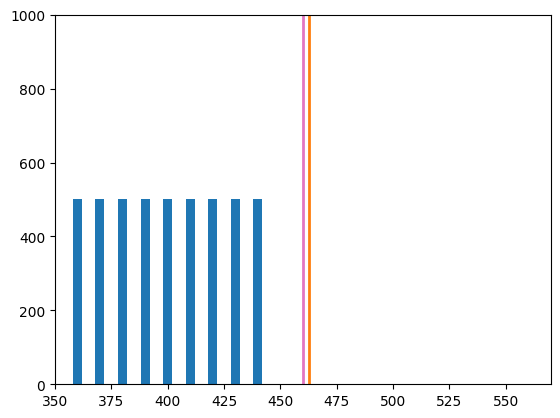

In [2]:
from pprint import pprint
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

T = 100
P1 = 1.01
p0 = 100
MIN_PRICE = 0.00001

# 변동성
v = 10
delta_prices = np.random.normal(0, v, T)

# 가격
p = p0
prices = []
ticks = []
for dp in delta_prices:
    t = math.log(p, P1)
    ticks.append(t)
    prices.append(p)
    p = max(p + dp, MIN_PRICE)

# 시뮬레이션
users = ["alice", "bob"]
tick_spacing = 10
book = OrderBook(int((ticks[0] // tick_spacing) * tick_spacing), tick_spacing)
# 데이터
bucket_ids = {}
state = {
    "ticks": [],
    "buckets": []
}

t0 = int((ticks[0] // tick_spacing) * tick_spacing)

def calc_liq(p, x, y):
    # L = px + y
    return p*x + y

def calc_x(p, liq, y):
    return (liq - y) / p

def calc_y(p, liq, x):
    return liq - p*x

# 균일한 유동성
L = 500
for i in range(0, 10):
    tick = t0 + (i + 2) * tick_spacing
    # 유동성 = p*x + y
    p = P1 ** tick
    book.inc(
        tick,
        True,
        calc_x(p, L, 0),
        msg_sender = "alice"
    )
    bucket_ids[book.get_bucket_id(tick)] = {"tick": tick}

    tick = t0 - (i + 2) * tick_spacing
    book.inc(
        tick,
        False,
        calc_y(p, L, 0),
        msg_sender = "bob"
    )
    bucket_ids[book.get_bucket_id(tick)] = {"tick": tick}

for t in range(0, T):
    # 검사
    # 현재 틱에서 먼 주문 취소
    # 현재 틱 근처에 주문 배치
    # for i in range(0, random.randint(0, 10)):
    #     d_tick = random.randint(-10, 10)
    #     tick = int((ticks[t] // tick_spacing + d_tick) * tick_spacing)
    #     if tick != book.tick:
    #         amt = random.randint(1, 100)
    #         zero_to_one = book.tick < tick
    #         book.inc(
    #             tick,
    #             zero_to_one,
    #             amt,
    #             # 무작위 사용자
    #             msg_sender = users[i % len(users)]
    #         )
    #         bucket_ids[book.get_bucket_id(tick)] = {"tick": tick}
    # 스왑
    try:
        # TODO: 현재 틱까지 스왑
        tick = ticks[t]
        p = P1**tick
        # delta_liq = random.randint(-10, 10)
        delta_liq = 1
        if delta_liq != 0:
            # zero_to_one = tick < book.tick
            zero_to_one = random.random() < 0.5
            # tick_limit = tick - tick_spacing if zero_to_one else tick + tick_spacing
            tick_limit = -1000000 if zero_to_one else 1000000
            amt_limit = 0 if delta_liq > 0 else 1000000000
            (amt_in, amt_out) = book.swap(
                (- calc_y(delta_liq, p, 0)) if zero_to_one else (- calc_x(delta_liq, p, 0)),
                amt_limit,
                tick_limit,
                zero_to_one
            )
            # print("0 -> 1:", zero_to_one, "in:", amt_in, "out:", amt_out)
    except Exception as e:
        print(f'Swap error at time {t}:', e)
    # 수령

    # 상태 데이터 수집
    if t == 0:
        s = book.slots.get(book.tick)
        bucket = book.buckets.get(book.tick, {}).get(s, None)
        print(t, book.tick, s, bucket)
        for i, s in book.slots.items():
            bucket = book.buckets.get(i, {}).get(s, None)
            print(i, s, bucket)
    state["ticks"].append(book.tick)
    state["buckets"].append({})
    for i, s in book.slots.items():
        bucket = book.buckets.get(i, {}).get(s, None)
        if bucket:
            state["buckets"][-1][i] = {
                "tick": bucket_ids[i]["tick"],
                "zero_to_one": bucket.zero_to_one,
                "amt0": bucket.amt0,
                "amt1": bucket.amt1,
            }

    # 검사
    for i, slot in book.slots.items():
        tick = bucket_ids[i]["tick"]
        for s in range(0, slot + 1):
            bucket = book.buckets.get(i, {}).get(s, None)
            if s < slot:
                assert bucket != None
                if bucket.zero_to_one:
                    assert bucket.amt0 == 0
                    assert bucket.amt1 > 0
                else:
                    assert bucket.amt0 > 0
                    assert bucket.amt1 == 0
            else:
                if bucket != None:                    
                    if tick < book.tick:
                        assert not bucket.zero_to_one
                        assert bucket.amt0 == 0
                        assert bucket.amt1 > 0
                    elif tick > book.tick:
                        assert bucket.zero_to_one
                        assert bucket.amt0 > 0
                        assert bucket.amt1 == 0
                    else:
                        assert bucket.amt0 >= 0
                        assert bucket.amt1 >= 0


data = [{"pirce": p, "tick": t, "buckets": b, "book_tick": bt}  for (p, t, b, bt) in zip(prices, ticks, state["buckets"], state["ticks"])]

# 그래프
Y_MAX = 1000
MIN_TICK_DELTA = -100
MAX_TICK_DELTA = 100
t0 = int(ticks[0] // tick_spacing * tick_spacing)
x_ticks = nums = [t0 + t for t in range(MIN_TICK_DELTA, MAX_TICK_DELTA + 1, tick_spacing)]
x_ticks_to_idx = {value: idx for idx, value in enumerate(x_ticks)}

fig, ax = plt.subplots()

ax.set_xlim(t0 + MIN_TICK_DELTA - tick_spacing, t0 + MAX_TICK_DELTA + tick_spacing)
ax.set_ylim(0, Y_MAX)

vlines = []
for (tick, color) in zip([t0, t0], ["tab:orange", "tab:pink"]):
    line, = ax.plot([tick, tick], [0, Y_MAX], color=color, lw=2)
    vlines.append(line)

# x_ticks 위치에 높이가 0인 막대 생성
bars_red = ax.bar(x_ticks, [0]*len(x_ticks), color="tab:red", width=4)
bars_blue = ax.bar(x_ticks, [0]*len(x_ticks), color="tab:blue", width=4, bottom=[0]*len(x_ticks))

def update(frame):
    vals = data[frame]

    # 모든 막대의 높이를 0으로 초기화
    for r, b in zip(bars_red, bars_blue):
        r.set_height(0)
        b.set_y(0)
        b.set_height(0)
    
    for b in vals["buckets"].values():
        tick = b["tick"]
        p = P1**tick
        x = b["amt0"]
        y = b["amt1"]
        if tick not in x_ticks_to_idx:
            continue
        idx = x_ticks_to_idx[tick]
        assert 0 <= idx < len(bars_red), f'idx: {idx}, len red: {len(bars_red)}'
        assert 0 <= idx < len(bars_blue), f'idx: {idx}, len blue: {len(bars_blue)}'
        bars_red[idx].set_height(calc_liq(p, x, 0))
        bars_blue[idx].set_y(calc_liq(p, x, 0))
        bars_blue[idx].set_height(calc_liq(p, 0, y))

    ticks = [vals["tick"], vals["book_tick"]]
    for (tick, line) in zip(ticks, vlines):
        line.set_data([tick, tick], [0, Y_MAX])    
            
    return bars_red + bars_blue

ani = FuncAnimation(fig, update, frames=range(0, T, 1), interval=500, blit=False, repeat=False)

# JupyterLab용
HTML(ani.to_jshtml())

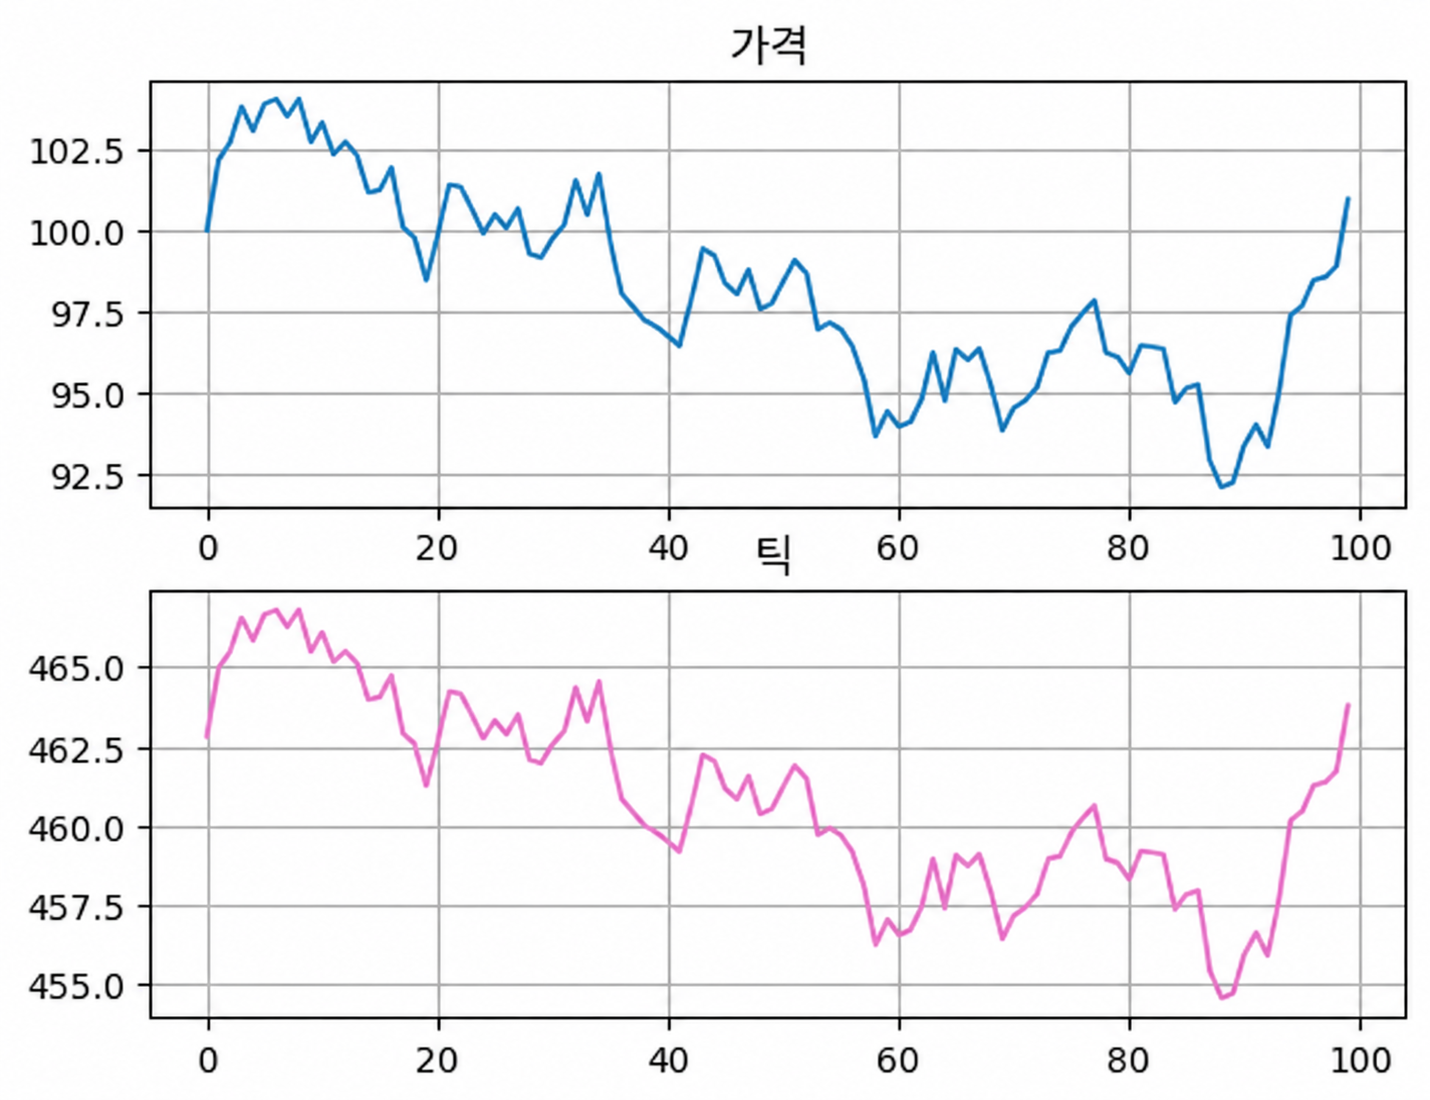

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

T = 100
# 초기 가격
P1 = 1.01
p0 = 100
MIN_PRICE = 0.00001
# 변동성
v = 1
delta_prices = np.random.normal(0, v, T)

# 가격
p = p0
prices = []
ticks = []
for dp in delta_prices:
    t = math.log(p, P1)
    ticks.append(t)
    prices.append(p)
    p = max(p + dp, MIN_PRICE)

# 서브플롯 2개 생성: 1행 2열
# (행 수, 열 수, 인덱스)
plt.subplot(2, 1, 1)
plt.title("가격")
plt.plot(prices)
plt.grid()

plt.subplot(2, 1, 2)
plt.title("틱")
plt.plot(ticks, color="tab:pink")
plt.grid()

plt.show()

In [15]:
import random
random.random()

0.27628154188114595

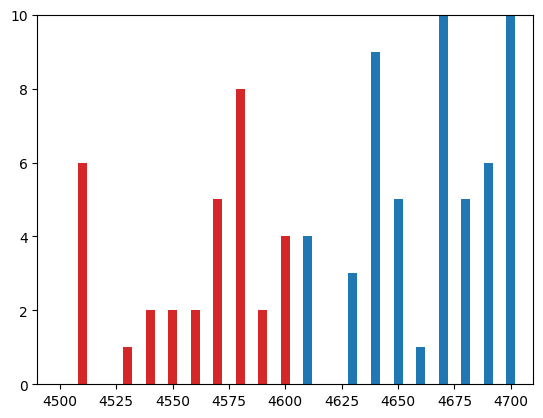

In [56]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

Y_MAX = 10
tick_spacing = 10
min_tick = -100
max_tick = 100
t0 = 4600
tick = t0

# 데이터
x_ticks = nums = [t0 + t for t in range(min_tick, max_tick + 1, tick_spacing)]

def generate_vals(tick):
    vals = []
    for t in x_ticks:
        if tick < t:
            y = random.randint(0, Y_MAX)
            vals.append((0, y))
        elif t < tick:
            x = random.randint(0, Y_MAX)
            vals.append((x, 0))
        else:
            x = random.randint(0, Y_MAX // 2)
            y = random.randint(0, Y_MAX // 2)
            vals.append((x, y))
    return vals

# 그래프
fig, ax = plt.subplots()

ax.set_xlim(t0 + min_tick - tick_spacing, t0 + max_tick + tick_spacing)
ax.set_ylim(0, Y_MAX)

bars_red = ax.bar(x_ticks, [0]*len(x_ticks), color="tab:red", width=4)
bars_blue = ax.bar(x_ticks, [0]*len(x_ticks), color="tab:blue", width=4, bottom=[0]*len(x_ticks))

def update(frame):
    # tick = ticks[frame]
    vals = generate_vals(tick)
    
    for i, (x, y) in enumerate(vals):
        bars_red[i].set_height(x)
        bars_blue[i].set_height(y)
        bars_blue[i].set_y(x)
        
    return bars_red + bars_blue

ani = FuncAnimation(fig, update, frames=range(0, 50, 1), interval=500, blit=False)

# JupyterLab용
HTML(ani.to_jshtml())